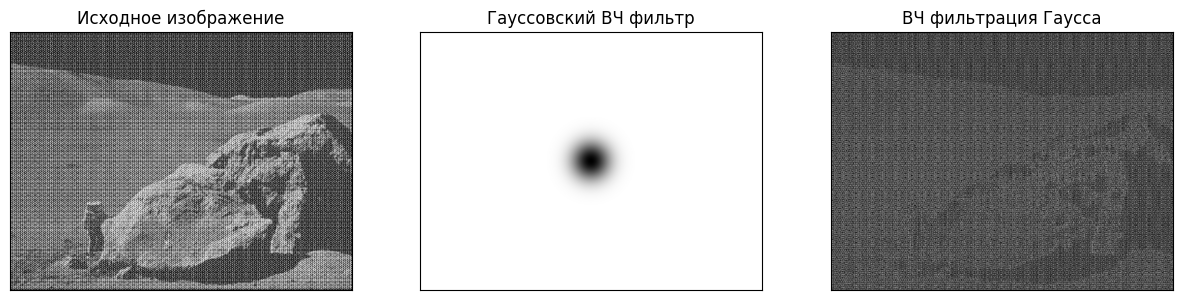

In [10]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max

img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)

dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

def gaussian_high_pass_filter(shape, cutoff):
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2
    
    
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - center_col)**2 + (y - center_row)**2)
    
   
    low_pass = np.exp(-(distance**2) / (2 * (cutoff**2)))
    
    
    high_pass = 1 - low_pass
    
    
    high_pass = np.stack([high_pass, high_pass], axis=2)
    
    return high_pass


cutoff_frequency = 30  
gaussian_hp_filter = gaussian_high_pass_filter(img.shape, cutoff_frequency)


filtered_dft_shift = dft_shift * gaussian_hp_filter


plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Исходное изображение'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(gaussian_hp_filter[:,:,0], cmap='gray')
plt.title('Гауссовский ВЧ фильтр'), plt.xticks([]), plt.yticks([])


f_ishift = np.fft.ifftshift(filtered_dft_shift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:,:,0], img_back[:,:,1])

plt.subplot(133), plt.imshow(img_back, cmap='gray')
plt.title('ВЧ фильтрация Гаусса'), plt.xticks([]), plt.yticks([])
plt.show()

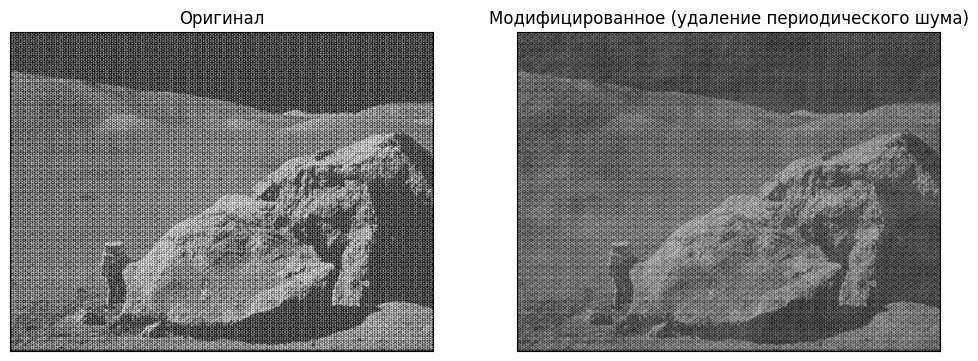

In [11]:
dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))

local_max = peak_local_max(magnitude_spectrum, min_distance=15, threshold_abs=200)
rows, cols = img.shape
mask = np.copy(dft_shift)
mask[:, :, :] = 1

for i in local_max:
    r = np.int32(((i[0] - rows // 2)**2 + (i[1] - cols // 2)**2)**(1 / 2))
    cv.circle(mask, (rows // 2, cols // 2), r, (0,0))

fshift = dft_shift * mask
img_back = cv.idft(np.fft.ifftshift(fshift))
img_back = cv.magnitude(img_back[:,:,0], img_back[:,:,1])


plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Оригинал'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('Модифицированное (удаление периодического шума)'), plt.xticks([]), plt.yticks([])
plt.show()